# LAB 4: Exploratory Data Analysis (EDA)

ARTI 308 – Machine Learning


Group Members

| Names | ID |
|---|---|
| Arwa Alkhathlan | 2250030009 |
| Noor Albuainain | 2250030050 |
| Zainab Alharbi | 2250030246 |
| Joud Albeijan | 2250030261 |
| Sheehana Alghamdi | 2250030084 |
| Reem Alshehab | 2250030257 |


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
f = pd.read_csv("cleaned_global_video_game_sales.csv")

### Check Missing Values

In [6]:
print(df.isna())

        Rank   Name  Platform   Year  Genre  Publisher  NA_Sales  EU_Sales  \
0      False  False     False  False  False      False     False     False   
1      False  False     False  False  False      False     False     False   
2      False  False     False  False  False      False     False     False   
3      False  False     False  False  False      False     False     False   
4      False  False     False  False  False      False     False     False   
...      ...    ...       ...    ...    ...        ...       ...       ...   
11465  False  False     False  False  False      False     False     False   
11466  False  False     False  False  False      False     False     False   
11467  False  False     False  False  False      False     False     False   
11468  False  False     False  False  False      False     False     False   
11469  False  False     False  False  False      False     False     False   

       JP_Sales  Other_Sales  Global_Sales  
0         False   

In [8]:
print(df.isna().sum())

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


### Check duplicate rows

In [9]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [10]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (11470, 11) 

number of rows:  11470
number of columns:  11


### Data type of columns

In [11]:
# viewing the data types of columns
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,int64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


In [12]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['NA_Sales'] = pd.to_numeric(df['NA_Sales'], errors='coerce')
df['EU_Sales'] = pd.to_numeric(df['EU_Sales'], errors='coerce')
df['JP_Sales'] = pd.to_numeric(df['JP_Sales'], errors='coerce')
df['Other_Sales'] = pd.to_numeric(df['Other_Sales'], errors='coerce')
df['Global_Sales'] = pd.to_numeric(df['Global_Sales'], errors='coerce')

df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,int64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


In [ ]:
# Statistical summary
df.describe(include='all')


### Descriptive summary Statistics



### Univariate Analysis

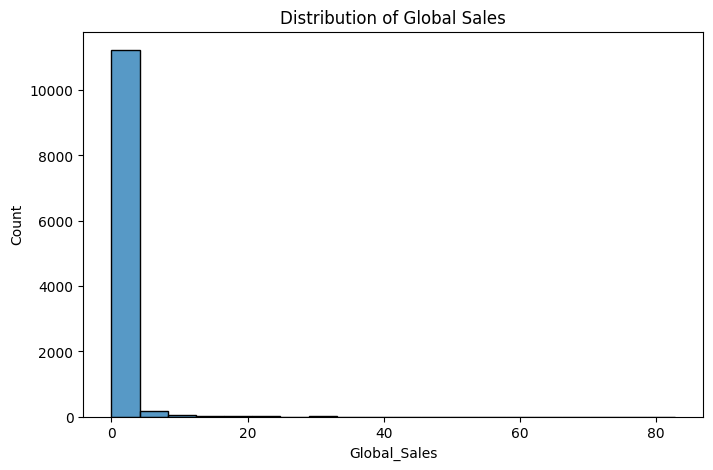

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['Global_Sales'], bins=20)

plt.title("Distribution of Global Sales")

plt.show()


- Shows how global video game sales are distributed
- Right skew = many games have relatively low sales, while a small number of games have very high sales

### Distribution of European Sales



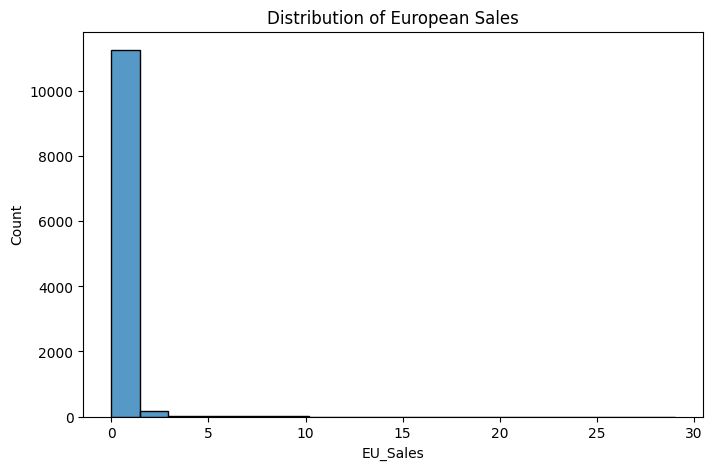

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['EU_Sales'], bins=20)

plt.title("Distribution of European Sales")

plt.show()

## Bivariate Analysis

### Sales by Region

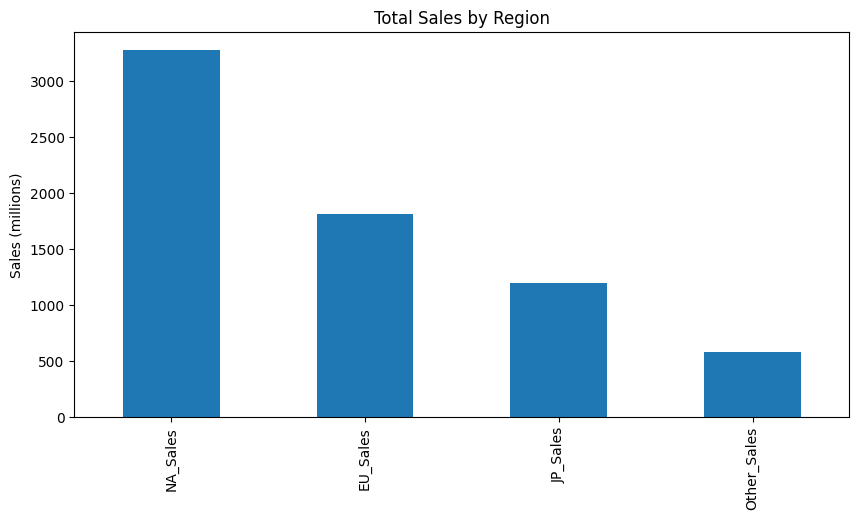

,0
NA_Sales,3274.55
EU_Sales,1808.98
JP_Sales,1194.66
Other_Sales,583.46


In [25]:
region_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(10,5))

region_sales.plot(kind='bar')

plt.title("Total Sales by Region")

plt.ylabel("Sales (millions)")

plt.show()

region_sales

### Global Sales by Genre

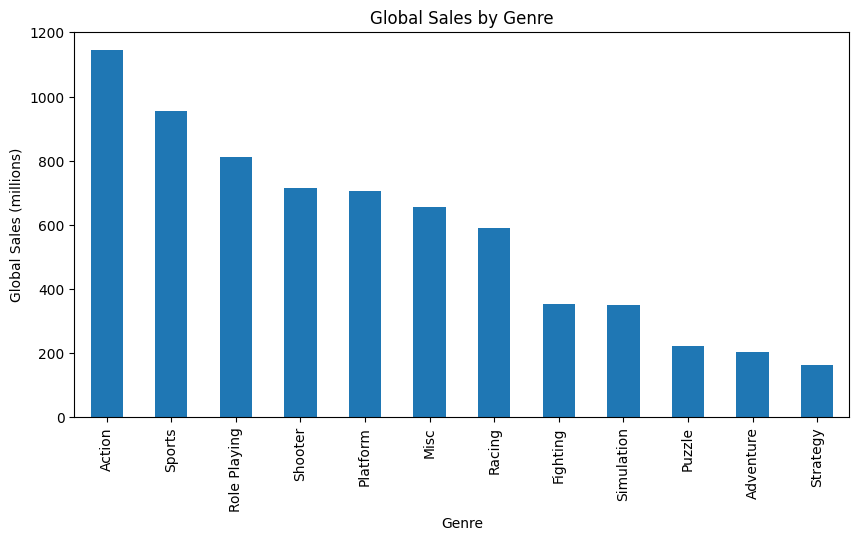

,Global_Sales
Genre,
Action,1144.77
Sports,953.67
Role Playing,812.35
Shooter,713.39
Platform,705.98
Misc,655.71
Racing,590.17
Fighting,353.46
Simulation,348.25


In [26]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

genre_sales.plot(kind='bar')

plt.title("Global Sales by Genre")

plt.ylabel("Global Sales (millions)")

plt.show()

genre_sales

### Global Sales by Publisher

In [27]:
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)

publisher_sales.head(10)

,Global_Sales
Publisher,
Nintendo,1706.13
Electronic Arts,655.01
Sony Computer Entertainment,575.61
Activision,398.04
Ubisoft,318.58
TakeTwo Interactive,245.96
Microsoft Game Studios,240.99
Konami Digital Entertainment,239.56
THQ,223.18


### NA Sales vs Global Sales Relationship

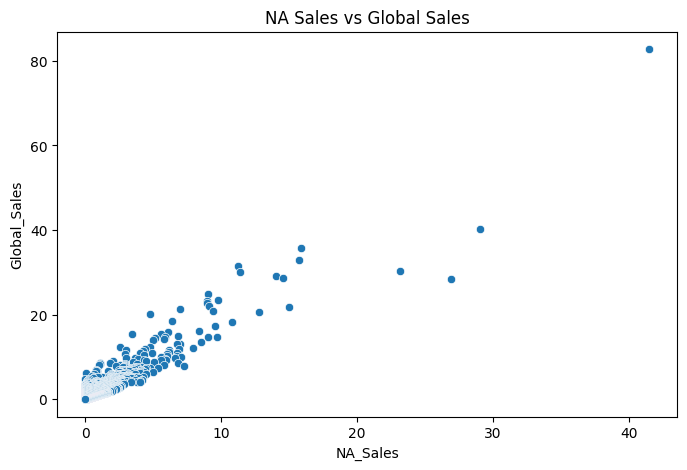

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='NA_Sales', y='Global_Sales', data=df)

plt.title("NA Sales vs Global Sales")

plt.show()

### Correlation Matrix

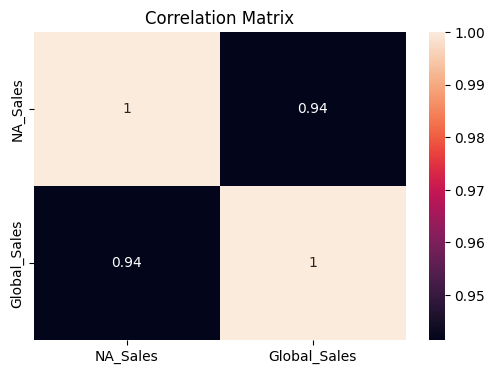

In [30]:
plt.figure(figsize=(6,4))

sns.heatmap(df[['NA_Sales', 'Global_Sales']].corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

- Correlation close to 1 = strong positive relationship between two sales regions.
- Correlation close to 0 = weak or little linear relationship between them.
- Correlation close to -1 = strong negative relationship.

## Time-Based Analysis

### Yearly Global Sales Trend

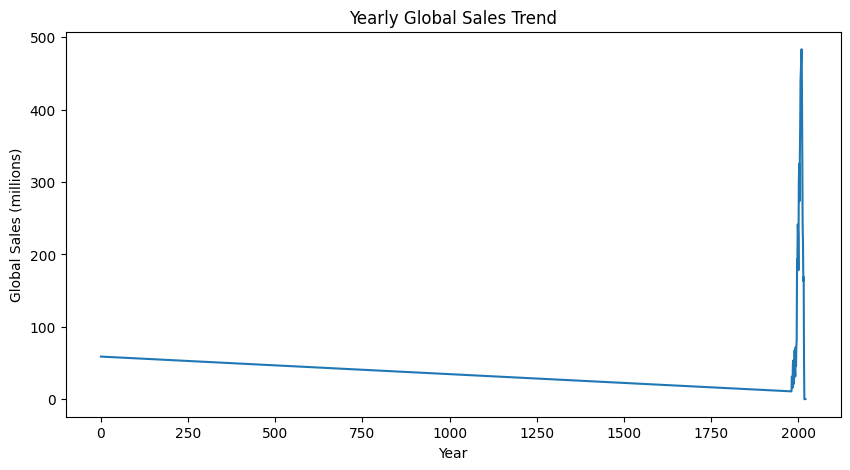

In [31]:
yearly_sales = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(10,5))

yearly_sales.plot()

plt.title("Yearly Global Sales Trend")

plt.ylabel("Global Sales (millions)")

plt.show()